# 🧪 OpenCV Coin Counter — Workshop Notebook  
**Date:** 2025-09-12

ภาษา: ไทย / English / 日本語

---

## 🎯 Objectives / 目的
- **TH:** เข้าใจภาพดิจิทัลเป็นข้อมูล + ทำ Gray, Blur, Threshold, Morphology, Contour เพื่อ **นับเหรียญ**
- **EN:** Understand images as data and use Gray, Blur, Threshold, Morphology, and Contours to **count coins**.
- **JP:** 画像をデータとして理解し、Gray・Blur・Threshold・Morphology・Contours を使って**硬貨を数える**。

**Tip:** คุณสามารถรันทีละ cell (Shift+Enter) — Run one cell at a time.


## 0) Setup / セットアップ
ถ้าคุณยังไม่มีไลบรารี ให้ติดตั้งครั้งเดียวเท่านั้น (Run once).

In [1]:
# If needed, uncomment the next line to install packages
# !pip install opencv-python numpy matplotlib ipywidgets

import sys, platform, os, math, time
import numpy as np
import cv2
import matplotlib.pyplot as plt

# For inline plots in notebooks
%matplotlib inline

print("Python:", sys.version)
print("OpenCV:", cv2.__version__)
print("OS:", platform.platform())

Python: 3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]
OpenCV: 4.12.0
OS: Windows-11-10.0.26100-SP0


## Helper: Display utility  
ฟังก์ชันช่วยแสดงภาพใน Notebook / 画像表示のユーティリティ

In [2]:
def show(title, img, cmap=None, size=6):
    plt.figure(figsize=(size, size * (img.shape[0]/img.shape[1]) if img.ndim==3 else size))
    if img.ndim == 2:
        plt.imshow(img, cmap=cmap or 'gray')
    else:
        # Convert BGR (OpenCV) to RGB (matplotlib)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

---
## 1) Camera Preview & Snapshot / カメラプレビューとスナップショット

- **TH:** เปิดกล้องและกด `s` เพื่อบันทึกภาพเป็น `coins.jpg` (กด `q` เพื่อออก)  
- **EN:** Open the camera and press `s` to save `coins.jpg` (press `q` to quit).  
- **JP:** カメラを開き、`s` で `coins.jpg` を保存（`q` で終了）。  
**Note:** บางสภาพแวดล้อมไม่รองรับหน้าต่าง OpenCV ในโน้ตบุ๊ก—ให้รันเป็นสคริปต์ .py ก็ได้


In [3]:
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("⚠️ Cannot open camera. Try changing index (0→1) or run as .py script.")
else:
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1920)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 1080)
    print("Press 's' to save coins.jpg, 'q' to quit.")
    while True:
        ok, frame = cap.read()
        if not ok:
            print("Frame read failed."); break
        cv2.imshow("Camera", frame)
        k = cv2.waitKey(1) & 0xFF
        if k == ord('s'):
            cv2.imwrite("coins.jpg", frame)
            print("Saved: coins.jpg")
        if k == ord('q'):
            break
    cap.release(); cv2.destroyAllWindows()

Press 's' to save coins.jpg, 'q' to quit.
Saved: coins.jpg


---
## 2) Preprocess: Gray & Blur / 前処理：グレースケールとブラー

- **TH:** แปลงเป็นขาวดำและเบลอเพื่อลดนอยส์  
- **EN:** Convert to grayscale and apply Gaussian blur to reduce noise.  
- **JP:** グレースケールに変換し、ノイズ低減のためにガウシアンブラーを適用。

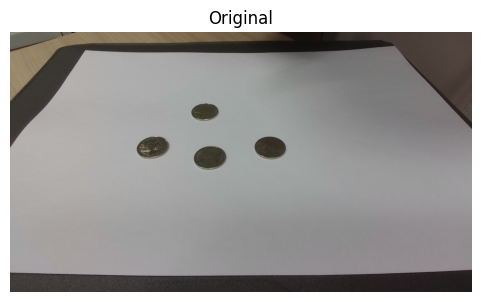

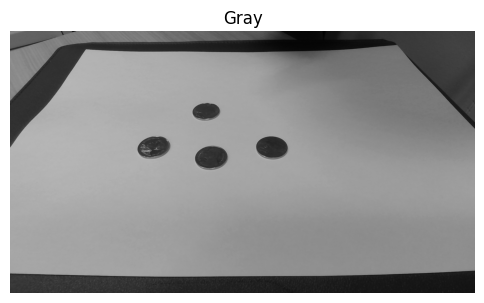

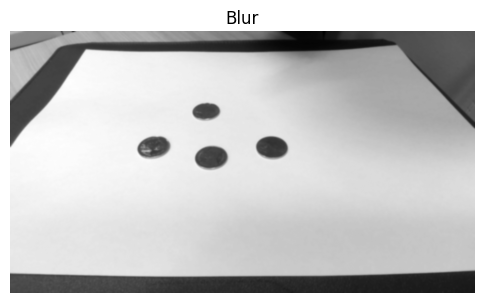

In [4]:
img = cv2.imread("coins.jpg")
assert img is not None, "Please capture coins.jpg in the previous step."

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (15, 15), 0)

cv2.imwrite("out_gray.jpg", gray)
cv2.imwrite("out_blur.jpg", blur)

show("Original", img)
show("Gray", gray)
show("Blur", blur)

---
## 3) Adaptive Threshold + Morphology / 適応的二値化 + 形態学的処理

- **TH:** ใช้ Adaptive Threshold เพื่อรับมือแสงไม่สม่ำเสมอ และใช้ Closing ปิดช่องว่าง  
- **EN:** Use Adaptive Threshold for uneven lighting and Closing to fill gaps.  
- **JP:** 不均一な照明に対して適応的二値化、隙間を埋めるためにクロージング。

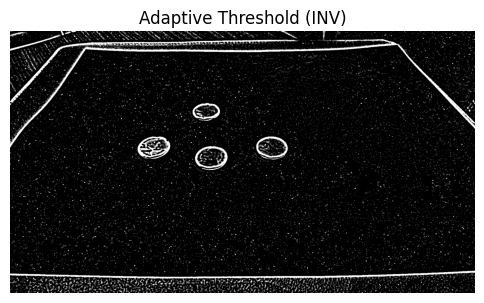

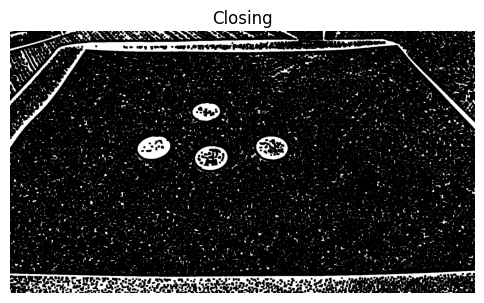

In [5]:
th_adapt = cv2.adaptiveThreshold(
    blur, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    11, 1
)
kernel = np.ones((3,3), np.uint8)
closing = cv2.morphologyEx(th_adapt, cv2.MORPH_CLOSE, kernel, iterations=3)

cv2.imwrite("out_thresh_adaptive.jpg", th_adapt)
cv2.imwrite("out_closing.jpg", closing)

show("Adaptive Threshold (INV)", th_adapt)
show("Closing", closing)

### (Alt) Otsu Threshold / 大津の二値化（代替）  
ลอง Otsu เพื่อเปรียบเทียบ / Compare with Adaptive

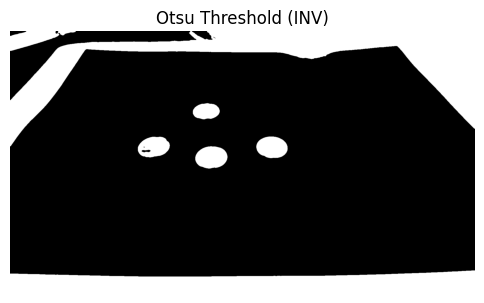

In [6]:
_, th_otsu = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
show("Otsu Threshold (INV)", th_otsu)

---
## 4) Count Coins with Contours / 輪郭で硬貨をカウント

- **TH:** หา Contour เฉพาะด้านนอก แล้วกรองด้วยพื้นที่ (area)  
- **EN:** Find external contours and filter by area.  
- **JP:** 外側の輪郭を検出し、面積でフィルタリング。

Coins: 4


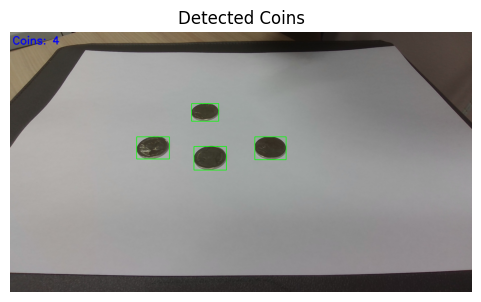

In [7]:
binary = closing.copy()  # or th_otsu
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

count = 0
vis = img.copy()
for c in contours:
    area = cv2.contourArea(c)
    if 5000 < area < 35000:
        x,y,w,h = cv2.boundingRect(c)
        cv2.rectangle(vis, (x,y), (x+w, y+h), (0,255,0), 2)
        count += 1

cv2.putText(vis, f"Coins: {count}", (10,50),
            cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255,0,0), 3)
cv2.imwrite("out_count.jpg", vis)

print("Coins:", count)
show("Detected Coins", vis)

---
## 5) Interactive Tuner (Optional) / インタラクティブ調整（任意）

- **TH:** ปรับค่าพารามิเตอร์ด้วยสไลเดอร์เพื่อดูผลลัพธ์ทันที
- **EN:** Adjust parameters with sliders to see instant effects.
- **JP:** スライダーでパラメータを調整し、結果を即時に確認。

> Requires `ipywidgets`. If not available, skip this section.


In [9]:
try:
    import ipywidgets as W
    from IPython.display import display, clear_output

    def process(blur_k=15, block=11, C=1, morph_k=3, morph_it=3, area_min=5000, area_max=35000):
        # enforce odd numbers for kernels
        blur_k = int(blur_k) if int(blur_k)%2==1 else int(blur_k)+1
        block = int(block) if int(block)%2==1 else int(block)+1
        morph_k = int(morph_k) if int(morph_k)%2==1 else int(morph_k)+1

        g = cv2.GaussianBlur(gray, (blur_k, blur_k), 0)
        th = cv2.adaptiveThreshold(g, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, block, int(C))
        kernel = np.ones((morph_k, morph_k), np.uint8)
        cl = cv2.morphologyEx(th, cv2.MORPH_CLOSE, kernel, iterations=int(morph_it))

        cnts, _ = cv2.findContours(cl, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        vis2 = img.copy()
        count2 = 0
        for c in cnts:
            area = cv2.contourArea(c)
            if int(area_min) < area < int(area_max):
                x,y,w,h = cv2.boundingRect(c)
                cv2.rectangle(vis2, (x,y), (x+w, y+h), (0,255,0), 2)
                count2 += 1

        show(f"Binary (block={block}, C={C})", th)
        show(f"Closing (k={morph_k}, it={morph_it})", cl)
        show(f"Detected Coins: {count2}", vis2)

    ui = W.interactive(
        process,
        blur_k=W.IntSlider(value=15, min=3, max=31, step=2),
        block=W.IntSlider(value=11, min=3, max=25, step=2),
        C=W.IntSlider(value=1, min=-10, max=10, step=1),
        morph_k=W.IntSlider(value=3, min=1, max=15, step=2),
        morph_it=W.IntSlider(value=3, min=1, max=7, step=1),
        area_min=W.IntSlider(value=5000, min=100, max=20000, step=100),
        area_max=W.IntSlider(value=35000, min=5000, max=80000, step=500)
    )
    display(ui)
except Exception as e:
    print("ipywidgets not available or failed to load:", e)

interactive(children=(IntSlider(value=15, description='blur_k', max=31, min=3, step=2), IntSlider(value=11, de…

---
## ✅ Wrap-up / まとめ
- Pipeline: **Gray → Blur → Threshold → Morphology → Contours**  
- เปลี่ยนแสง/ฉากหลัง → ปรับพารามิเตอร์ให้ทนขึ้น